In [ ]:
# Step 1 - Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
# Step 2 - Load Dataset
data = pd.read_csv("customer_clustering.csv")

In [ ]:
# Display first 5 rows
print(data.head())

   Customer_ID  Age  Annual_Income  Spending_Score  Online_Purchases
0            1   18             15              20                 5
1            2   20             18              25                 7
2            3   22             20              22                 6
3            4   25             35              60                20
4            5   27             38              65                22


In [ ]:
X = data.iloc[:,1:]

In [ ]:
print("\nFeatures Used For Clustering:")
print(X.head())


Features Used For Clustering:
   Age  Annual_Income  Spending_Score  Online_Purchases
0   18             15              20                 5
1   20             18              25                 7
2   22             20              22                 6
3   25             35              60                20
4   27             38              65                22


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
wcss = []

In [ ]:
for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=0,
        n_init=10 # Added n_init to suppress future warnings
    )
    model.fit(X_scaled)
    wcss.append(model.inertia_)

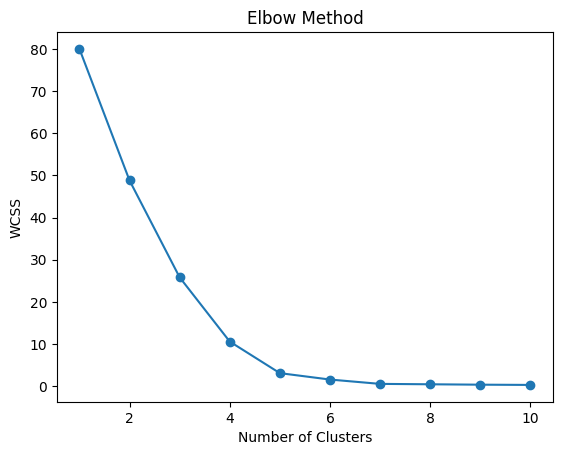

In [ ]:
# Plot Elbow Graph
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=0
)

In [ ]:
kmeans.fit(X_scaled)

KMeans(n_clusters=4, random_state=0)

In [ ]:
clusters = kmeans.labels_

# Add cluster column
data["Cluster"] = clusters


In [ ]:
print("\nClustered Data:\n")
print(data)


Clustered Data:

    Customer_ID  Age  Annual_Income  Spending_Score  Online_Purchases  Cluster
0             1   18             15              20                 5        3
1             2   20             18              25                 7        3
2             3   22             20              22                 6        3
3             4   25             35              60                20        2
4             5   27             38              65                22        2
5             6   26             36              62                21        2
6             7   35             60              40                15        1
7             8   37             62              42                14        1
8             9   36             58              39                13        1
9            10   45             80              85                30        0
10           11   47             82              88                32        0
11           12   46             7

In [ ]:
print("\nCluster Centers:\n")
print(kmeans.cluster_centers_)


Cluster Centers:

[[ 0.94108878  1.08983654  1.49082432  1.57243148]
 [ 0.94108878  0.88986653 -0.86534321 -0.74231537]
 [-0.60675461 -0.54991752  0.53915906  0.46993352]
 [-1.20525405 -1.40312288 -1.19789538 -1.3409568 ]]


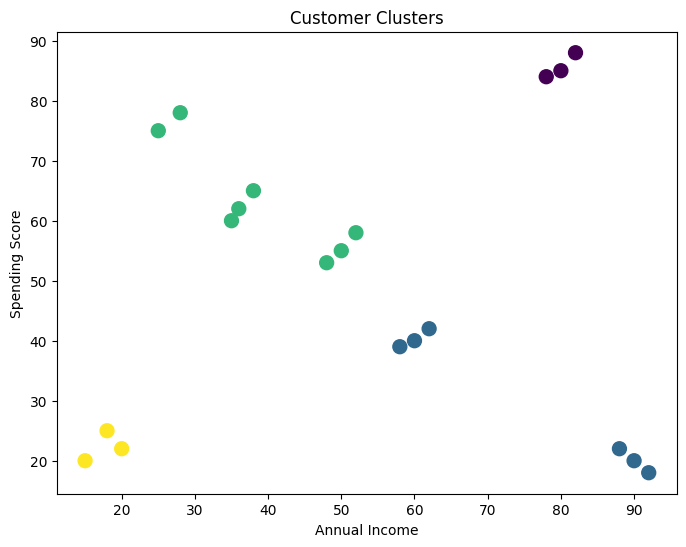

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    data["Annual_Income"],
    data["Spending_Score"],
    c=data["Cluster"],
    s=100
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Clusters")

plt.show()

In [ ]:
print("\nCluster Meaning:")


Cluster Meaning:


In [ ]:
print("Cluster 0 -> High Income High Spending")
print("Cluster 1 -> Low Income Low Spending")
print("Cluster 2 -> Average Customers")
print("Cluster 3 -> Young Online Buyers")

Cluster 0 -> High Income High Spending
Cluster 1 -> Low Income Low Spending
Cluster 2 -> Average Customers
Cluster 3 -> Young Online Buyers
